# Holo + Apo Multi-panel Figure

This notebook reads the already-prepared holo and apo model outputs and image assets from the original notebooks, without modifying those notebooks.

In [1]:
import pickle
from pathlib import Path
from string import ascii_lowercase

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR.parents[1]
HOLO_DIR = BASE_DIR.parent / "other_tools"
APO_DIR = BASE_DIR.parent / "other_tools_apos"
OUTPUT_DIR = BASE_DIR #/ "images"
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    "orange": "#d55e00",
    "green": "#009e73",
    "blue": "#0072b2",
    "yellow": "#f0e442",
}

# The only intentionally hardcoded domain-specific ordering: panel order based on holo PDBs.
HOLO_PANEL_ORDER = [
    "6vvq", "8uk6", "6s3a", "22mj", "21du",
    "8qtk", "9oul", "8y6w",
    "8jp0", "9prs", "7gqu",
    "9fsj", "8v81", "7qpn",
    "7yg5", "8crc", "8f4s",
    "9mfs", "9ebs", "7p2v",
    "7zpe", "9dol", "8fpi",
                    "6z1m",
]
EMPTY_SLOTS = (19, 20) # Slot index (counting from row 2 only, left-to-right then top-to-bottom) left blank.

HOLO_EXTRA_SET = PROJECT_DIR / "training_data/7.Extra_set"
APO_EXTRA_SET = PROJECT_DIR / "training_data/8.Apos/Extra_set"

with open(APO_EXTRA_SET / "features.pkl", "rb") as f:
    apo_news = pickle.load(f)

with open(APO_EXTRA_SET / "apos.pkl", "rb") as f:
    apos = {
        holo: {apo: chains for apo, chains in mapping.items() if apo in apo_news}
        for holo, mapping in pickle.load(f).items()
    }

apos["7qpn"]["2gk9"] = ["A"]
# apos["9ntc"]["8yf0"] = ["A"]

HOLO_ORTHO_POCKETS = pd.read_pickle(HOLO_DIR / "ortho_pockets.pkl")
APO_ORTHO_POCKETS = pd.read_pickle(APO_DIR / "ortho_pockets.pkl")

APO_REPRESENTATIVES = {
    holo: tuple(mapping.keys())[0]
    for holo, mapping in apos.items()
    if mapping and holo in HOLO_PANEL_ORDER
}

HOLO_ONLY_ORDER = [pdb for pdb in HOLO_PANEL_ORDER if pdb not in APO_REPRESENTATIVES]
COMBINED_HOLO_ORDER = [pdb for pdb in HOLO_PANEL_ORDER if pdb in APO_REPRESENTATIVES]

HOLO_NAMES = {pdb: pdb for pdb in HOLO_PANEL_ORDER}
APO_NAMES = {pdb: pdb for pdb in APO_REPRESENTATIVES.values()}
PANEL_TITLES = {
    holo: f"{HOLO_NAMES[holo]} | {APO_NAMES[apo]}"
    for holo, apo in APO_REPRESENTATIVES.items()
}
PANEL_TITLES.update({holo: HOLO_NAMES[holo] for holo in HOLO_ONLY_ORDER})

# assert len(HOLO_ONLY_ORDER) == 5
# assert len(COMBINED_HOLO_ORDER) == 19
assert set(COMBINED_HOLO_ORDER) == set(APO_REPRESENTATIVES)


def get_rendered_image_path(images_dir, pdb):
    images_dir = Path(images_dir)
    matches = sorted(images_dir.glob(f"{pdb}_*.png"))
    if matches:
        return matches[0]

    legacy = images_dir / f"{pdb}.png"
    if legacy.is_file():
        return legacy

    raise FileNotFoundError(f"Missing rendered PNG for {pdb} in {images_dir}")


plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"


In [2]:
def build_model5_labelled(models, excluded_pdbs=()):
    model5 = models["model5"]
    if "labelled" in model5:
        return model5["labelled"].copy()

    results = model5["results"]
    df = pd.DataFrame(
        {
            "pdb": pdb,
            "pocket": pocket,
            **pocketd,
        }
        for pdb, pockets in results.items()
        if pdb not in set(excluded_pdbs)
        for pocket, pocketd in pockets.items()
    )

    df["pred"] = (
        df.groupby("pdb")["label"].transform("sum")
        .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
        >= 0
    ).astype(int)

    for pdb, group in df.groupby("pdb"):
        if group["pred"].sum() == 0:
            df.loc[group["prob"].idxmax(), "pred"] = 1

    return df


holo_models = pd.read_pickle(HOLO_DIR / "models.pkl")
apo_models = pd.read_pickle(APO_DIR / "models_lenient_labelling.pkl")

holo_df = build_model5_labelled(holo_models, excluded_pdbs=("9dnm",))
apo_df = build_model5_labelled(apo_models, excluded_pdbs=("4jqi",))

holo_df = holo_df[holo_df["pdb"].isin(HOLO_ONLY_ORDER + COMBINED_HOLO_ORDER)].copy()
apo_df = apo_df[apo_df["pdb"].isin(APO_REPRESENTATIVES.values())].copy()

holo_df.sort_values(["pdb", "prob"], ascending=[True, False], inplace=True)
apo_df.sort_values(["pdb", "prob"], ascending=[True, False], inplace=True)

holo_df.head(), apo_df.head()


(    pdb   pocket      prob  pred  label  max_overlap  pocket_in_site  \
 1  21du  pocket1  0.101666     1      0          0.0             0.0   
 6  21du  pocket5  0.057728     0      0          0.0             0.0   
 8  21du  pocket3  0.003441     0      0          0.0             0.0   
 4  21du  pocket9  0.000965     0      0          0.0             0.0   
 7  21du  pocket8  0.000595     0      0          0.0             0.0   
 
    site_in_pocket  
 1             0.0  
 6             0.0  
 8             0.0  
 4             0.0  
 7             0.0  ,
      pdb    pocket      prob  pred  label  max_overlap  pocket_in_site  \
 5   2gk9   pocket1  0.614772     1      1     0.409091        0.290323   
 13  2gk9  pocket12  0.113857     0      0     0.000000        0.000000   
 1   2gk9  pocket15  0.009479     0      0     0.857143        0.857143   
 3   2gk9  pocket13  0.008256     0      0     0.000000        0.000000   
 2   2gk9   pocket7  0.002068     0      0     0.000000   

In [3]:
BASE_SCATTER_CONFIG = {
    "point_size": 100,  # Marker size for the scatter points.
    "jitter_width": 0.2,  # Maximum horizontal spread of the beeswarm offsets.
    "grey_alpha": 0.3,  # Opacity used for points in the background grey class.
    "axis_linewidth": 0.8,  # Line width of the visible right-hand y-axis spine.
    "tick_fontsize": 11.8,  # Font size of the y-axis tick labels.
    "label_fontsize": 12.8,  # Font size of the max-score numeric annotation.
    "xlabel_fontsize": 11.8,  # Font size of the '(n = ...)' label below each scatterplot.
    "score_title_fontsize": 13.4,  # Font size of the 'AlloPockets score' title above each scatterplot.
    "score_title_y": 1.12,  # Vertical offset of the scatterplot title in x-axis coordinates.
    "annotation_x_offset": 0.6,  # Horizontal offset multiplier used for the max-score annotation.
    "yticks": [0.0, 0.25, 0.5, 0.75, 1.0],  # Explicit y-tick locations used on every scatterplot.
    "ylabel_right_spine_position": 0.8125,  # Axes-relative x-position of the visible right-hand y-axis spine.
    "light_grey": "0.75",  # Color used for points that are neither predicted nor labelled.
    "xlabel_color": "0.35",  # Text color of the '(n = ...)' label below each scatterplot.
}

DATASET_SCATTER_CONFIGS = {
    "holo": {
        **BASE_SCATTER_CONFIG,
        "special_nbins": {"8crc": 1, "7u4k": 1},  # Per-PDB override for the beeswarm bin count.
        "blue_x_shift_by_pdb": {"9mfs": -0.05},  # Per-PDB x-shift for blue-only points.
        "ortho_pockets": HOLO_ORTHO_POCKETS,  # Mapping of holo PDBs to pockets highlighted as orthosteric overlaps.
        "ortho_skip_pdbs": {"7gqu", "9prs"},  # Holo PDBs where the orthosteric highlight is suppressed (overlap with allosteric).
    },
    "apo": {
        **BASE_SCATTER_CONFIG,
        "special_nbins": {"9di9": 1},  # Per-PDB override for the beeswarm bin count.
        "blue_x_shift_by_pdb": {"9di9": -0.125},  # Per-PDB x-shift for blue-only points.
        "ortho_pockets": APO_ORTHO_POCKETS,  # Mapping of apo PDBs to pockets highlighted as orthosteric overlaps.
        "ortho_skip_pdbs": {"6yhr", "2gk9", "8yf0", "5c97"},  # Apo PDBs where the orthosteric highlight is intentionally suppressed.
    },
}


def get_beeswarm_offsets(probs, pdb_id, jitter_width, special_nbins=None):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0 or np.nanmax(probs) == np.nanmin(probs):
        return np.zeros_like(probs)

    nbins = (special_nbins or {}).get(pdb_id, 50)
    rng = np.random.default_rng(0)
    quant = np.round(
        nbins * (probs - np.nanmin(probs)) / (np.nanmax(probs) - np.nanmin(probs) + 1e-8)
    )
    order = np.argsort(quant + rng.normal(0, 1e-6, len(probs)))

    x_vals = np.zeros(len(probs))
    layer = 0
    last_bin = None
    for idx in order:
        if quant[idx] != last_bin:
            layer = 0
            last_bin = quant[idx]

        if layer == 0:
            offset = 0
        else:
            offset = (layer + 1) // 2
            if layer % 2 == 0:
                offset = -offset

        x_vals[idx] = offset
        layer += 1

    max_abs = np.max(np.abs(x_vals))
    if max_abs > 0:
        x_vals = x_vals / max_abs * jitter_width
    return x_vals


def get_scatter_point_color(row, config):
    ortho_pockets = config["ortho_pockets"]
    if row["pdb"] in ortho_pockets and row["pdb"] not in config["ortho_skip_pdbs"]:
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return COLORS["yellow"]
    if row["pred"] and row["label"]:
        return COLORS["green"]
    if row["label"]:
        return COLORS["orange"]
    if row["pred"]:
        return COLORS["blue"]
    return config["light_grey"]


def plot_scatter_panel(pdb_id, df, ax, config, show_xlabel=True, show_score_title=True):
    sub = df.query("pdb == @pdb_id").copy()
    probs = sub["prob"].to_numpy(dtype=float)
    if len(probs) == 0 or np.all(np.isnan(probs)):
        raise ValueError(f"No valid probabilities found for {pdb_id}")

    sc_colors = np.array([get_scatter_point_color(row, config) for _, row in sub.iterrows()], dtype=object)
    alphas = np.array([
        config["grey_alpha"] if color == config["light_grey"] else 1
        for color in sc_colors
    ])
    x_vals = get_beeswarm_offsets(
        probs,
        pdb_id=pdb_id,
        jitter_width=config["jitter_width"],
        special_nbins=config["special_nbins"],
    )

    grey_mask = sc_colors == config["light_grey"]
    blue_mask = sc_colors == COLORS["blue"]
    color_mask = ~(grey_mask | blue_mask)

    ax.scatter(
        x_vals[grey_mask], probs[grey_mask], s=config["point_size"], c=sc_colors[grey_mask],
        alpha=alphas[grey_mask], edgecolors="none", zorder=1, clip_on=False,
    )
    if np.any(color_mask):
        ax.scatter(
            x_vals[color_mask], probs[color_mask], s=config["point_size"], c=sc_colors[color_mask],
            alpha=alphas[color_mask], edgecolors="none", zorder=2, clip_on=False,
        )

    blue_shift = config["blue_x_shift_by_pdb"].get(pdb_id, 0.0)
    if np.any(blue_mask):
        ax.scatter(
            x_vals[blue_mask] + blue_shift, probs[blue_mask], s=config["point_size"], c=sc_colors[blue_mask],
            alpha=alphas[blue_mask], edgecolors="none", zorder=3, clip_on=False,
        )

    idx_max = int(np.nanargmax(probs))
    text_val = f"{probs[idx_max]:.3f}".rstrip("0").rstrip(".")
    ax.text(
        x_vals[idx_max] - config["jitter_width"] * config["annotation_x_offset"] + blue_shift,
        probs[idx_max],
        text_val,
        ha="right",
        va="center",
        fontsize=config["label_fontsize"],
    )

    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, 1)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(config["axis_linewidth"])
    ax.spines["right"].set_position(("axes", config["ylabel_right_spine_position"]))

    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_yticks(config["yticks"])
    ax.set_yticklabels(["0", "", "0.5", "", "1"])
    ax.tick_params(axis="y", labelsize=config["tick_fontsize"])
    ax.set_ylabel("")

    if show_score_title:
        ax.text(
            0,
            config["score_title_y"],
            "AlloPockets\nscore",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            multialignment="center",
            fontsize=config["score_title_fontsize"],
        )

    ax.set_xlabel(
        f"(n = {len(sub)})" if show_xlabel else "",
        fontsize=config["xlabel_fontsize"],
        color=config["xlabel_color"],
    )
    if show_xlabel:
        ax.xaxis.set_label_coords(0.52, -0.075)

    ax.set_facecolor("none")
    ax.figure.patch.set_alpha(0.0)


In [ ]:
FIGURE_CONFIG = {
    "columns": 3,
    "rows": 8,
    "empty_panel_slots": EMPTY_SLOTS, # Slot index (counting rows 2–7 only, left-to-right then top-to-bottom) left blank.
    "figsize": (22.0, 32.0),  # Overall canvas size of the combined multi-panel figure in inches.
    "font_scale": 1.25,  # Global multiplier applied to the figure-level and scatterplot font sizes.
    "show_panel_title": False,  # Toggle whether each panel starts with a panel-level title line.
    "left": 0.035,  # Left outer figure margin used by the top-level GridSpec.
    "right": 0.985,  # Right outer figure margin used by the top-level GridSpec.
    "top": 0.99,  # Top outer figure margin used by the top-level GridSpec.
    "bottom": 0.02,  # Bottom outer figure margin used by the top-level GridSpec.
    "outer_hspace": 0.14,  # Vertical spacing between the seven major rows of panels.
    "top_row_wspace": 0.16,  # Horizontal spacing between the four holo-only panels in row 1.
    "combined_row_wspace": 0.18,  # Horizontal spacing between the three combined panels in rows 2–7.
    "panel_header_ratio": 0.12,  # Fraction of a panel's height reserved for the optional panel title line.
    "panel_hspace": 0.01,  # Vertical spacing between the optional panel title and the panel body.
    "item_group_wspace": 0.01,  # Horizontal spacing between the holo and apo item groups inside a combined panel.
    "item_title_ratio": 0.12,  # Fraction of an item group's height reserved for the per-structure PDB label.
    "item_hspace": 0.01,  # Vertical spacing between the per-structure PDB label and its image/scatter pair.
    "pair_wspace": 0.02,  # Horizontal spacing between the PNG area and the scatterplot area inside one item group.
    "pair_png_ratio": 0.72,  # Relative width allocated to the rendered structure PNG inside one item group.
    "pair_scatter_ratio": 0.32,  # Relative width allocated to the scatterplot inside one item group.
    "scatter_inset": [0.15, 0.21, 0.7, 0.62],  # [x0, y0, width, height] of the scatter inset inside its host axis.
    "protein_max_width": 0.94,  # Maximum normalized width occupied by a PNG inside its image slot.
    "protein_max_height": 1.0,  # Maximum normalized height occupied by a PNG inside its image slot.
    "panel_facecolor": "none",  # Background color of panel helper axes.
    "figure_facecolor": "none",  # Background color of the overall figure canvas.
    "header_fontsize": 15.5,  # Font size of the optional panel-level title line.
    "header_fontweight": "bold",  # Font weight of the optional panel-level title line.
    "item_label_fontsize": 15.0,  # Font size of the per-structure PDB labels above each holo/apo item.
    "item_label_fontweight": "bold",  # Font weight of the per-structure PDB labels above each holo/apo item.
    "output_path": OUTPUT_DIR / "holo_apo_multipanel.svg",  # Output path for the combined figure.
}

SCATTER_CONFIGS = {
    name: {
        **cfg,
        "special_nbins": dict(cfg["special_nbins"]),
        "blue_x_shift_by_pdb": dict(cfg["blue_x_shift_by_pdb"]),
        "ortho_pockets": dict(cfg["ortho_pockets"]),
        "ortho_skip_pdbs": set(cfg["ortho_skip_pdbs"]),
    }
    for name, cfg in DATASET_SCATTER_CONFIGS.items()
}

FIGURE_CONFIG["header_fontsize"] *= FIGURE_CONFIG["font_scale"]
FIGURE_CONFIG["item_label_fontsize"] *= FIGURE_CONFIG["font_scale"]
for cfg in SCATTER_CONFIGS.values():
    for key in ["tick_fontsize", "label_fontsize", "xlabel_fontsize", "score_title_fontsize"]:
        cfg[key] *= FIGURE_CONFIG["font_scale"]


def draw_centered_image(ax, image_path, max_width=0.94, max_height=0.94):
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing image asset: {image_path}")

    img = mpimg.imread(image_path)
    height, width = img.shape[:2]
    aspect = width / height

    disp_width = max_width
    disp_height = disp_width / aspect
    if disp_height > max_height:
        disp_height = max_height
        disp_width = disp_height * aspect

    x0 = (1 - disp_width) / 2
    x1 = x0 + disp_width
    y0 = (1 - disp_height) / 2
    y1 = y0 + disp_height

    ax.imshow(
        img,
        extent=(x0, x1, y0, y1),
        aspect="auto",
        interpolation="none",
        resample=False,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_facecolor("none")
    ax.axis("off")


def draw_item_group(fig, subspec, item, figure_config):
    image_on_right = item.get("image_on_right", False)
    total_width = figure_config["pair_png_ratio"] + figure_config["pair_scatter_ratio"]

    if image_on_right:
        width_ratios = [figure_config["pair_scatter_ratio"], figure_config["pair_png_ratio"]]
        scatter_idx, image_idx = 0, 1
        label_x = 1 - figure_config["pair_png_ratio"] / total_width / 2
    else:
        width_ratios = [figure_config["pair_png_ratio"], figure_config["pair_scatter_ratio"]]
        image_idx, scatter_idx = 0, 1
        label_x = figure_config["pair_png_ratio"] / total_width / 2

    group = subspec.subgridspec(
        2,
        1,
        height_ratios=[figure_config["item_title_ratio"], 1 - figure_config["item_title_ratio"]],
        hspace=figure_config["item_hspace"],
    )

    item_title_ax = fig.add_subplot(group[0])
    item_title_ax.set_facecolor(figure_config["panel_facecolor"])
    item_title_ax.axis("off")
    item_title_ax.text(
        label_x,
        0.55,
        item["display_id"],
        fontsize=figure_config["item_label_fontsize"],
        fontweight=figure_config["item_label_fontweight"],
        ha="center",
        va="center",
    )

    pair = group[1].subgridspec(
        1,
        2,
        width_ratios=width_ratios,
        wspace=figure_config["pair_wspace"],
    )

    image_ax = fig.add_subplot(pair[image_idx])
    image_ax.set_facecolor(figure_config["panel_facecolor"])
    draw_centered_image(
        image_ax,
        item["image_path"],
        max_width=figure_config["protein_max_width"],
        max_height=figure_config["protein_max_height"],
    )

    scatter_host_ax = fig.add_subplot(pair[scatter_idx])
    scatter_host_ax.set_facecolor(figure_config["panel_facecolor"])
    scatter_host_ax.axis("off")
    scatter_ax = scatter_host_ax.inset_axes(figure_config["scatter_inset"])
    scatter_ax.set_facecolor("none")
    plot_scatter_panel(
        item["pdb_id"],
        item["df"],
        ax=scatter_ax,
        config=item["scatter_config"],
        show_xlabel=True,
        show_score_title=True,
    )



def draw_panel(fig, subspec, panel_label, panel_title, items, figure_config):
    if figure_config["show_panel_title"]:
        panel = subspec.subgridspec(
            2,
            1,
            height_ratios=[figure_config["panel_header_ratio"], 1 - figure_config["panel_header_ratio"]],
            hspace=figure_config["panel_hspace"],
        )
        header_ax = fig.add_subplot(panel[0])
        header_ax.set_facecolor(figure_config["panel_facecolor"])
        header_ax.axis("off")
        header_ax.text(
            0.0,
            0.55,
            f"{panel_label} {panel_title}",
            fontsize=figure_config["header_fontsize"],
            fontweight=figure_config["header_fontweight"],
            ha="left",
            va="center",
        )
        body_spec = panel[1]
    else:
        body_spec = subspec

    body = body_spec.subgridspec(1, len(items), wspace=figure_config["item_group_wspace"])
    for idx, item in enumerate(items):
        draw_item_group(fig, body[idx], item, figure_config)


# assert 1 <= FIGURE_CONFIG["empty_panel_slot"] <= 18

combined_entries = [
    {
        "panel_title": PANEL_TITLES[holo],
        "items": [
            {
                "display_id": HOLO_NAMES[holo],
                "pdb_id": holo,
                "df": holo_df,
                "scatter_config": SCATTER_CONFIGS["holo"],
                "image_path": get_rendered_image_path(HOLO_DIR / "images", holo),
                "image_on_right": True,
            },
            {
                "display_id": APO_NAMES[APO_REPRESENTATIVES[holo]],
                "pdb_id": APO_REPRESENTATIVES[holo],
                "df": apo_df,
                "scatter_config": SCATTER_CONFIGS["apo"],
                "image_path": get_rendered_image_path(APO_DIR / "images", APO_REPRESENTATIVES[holo]),
            },
        ],
    }
    for holo in COMBINED_HOLO_ORDER
]

holo_only_entries = [
    {
        "panel_title": PANEL_TITLES[holo],
        "items": [
            {
                "display_id": HOLO_NAMES[holo],
                "pdb_id": holo,
                "df": holo_df,
                "scatter_config": SCATTER_CONFIGS["holo"],
                "image_path": get_rendered_image_path(HOLO_DIR / "images", holo),
                "image_on_right": True,
            }
        ],
    }
    for holo in HOLO_ONLY_ORDER
]

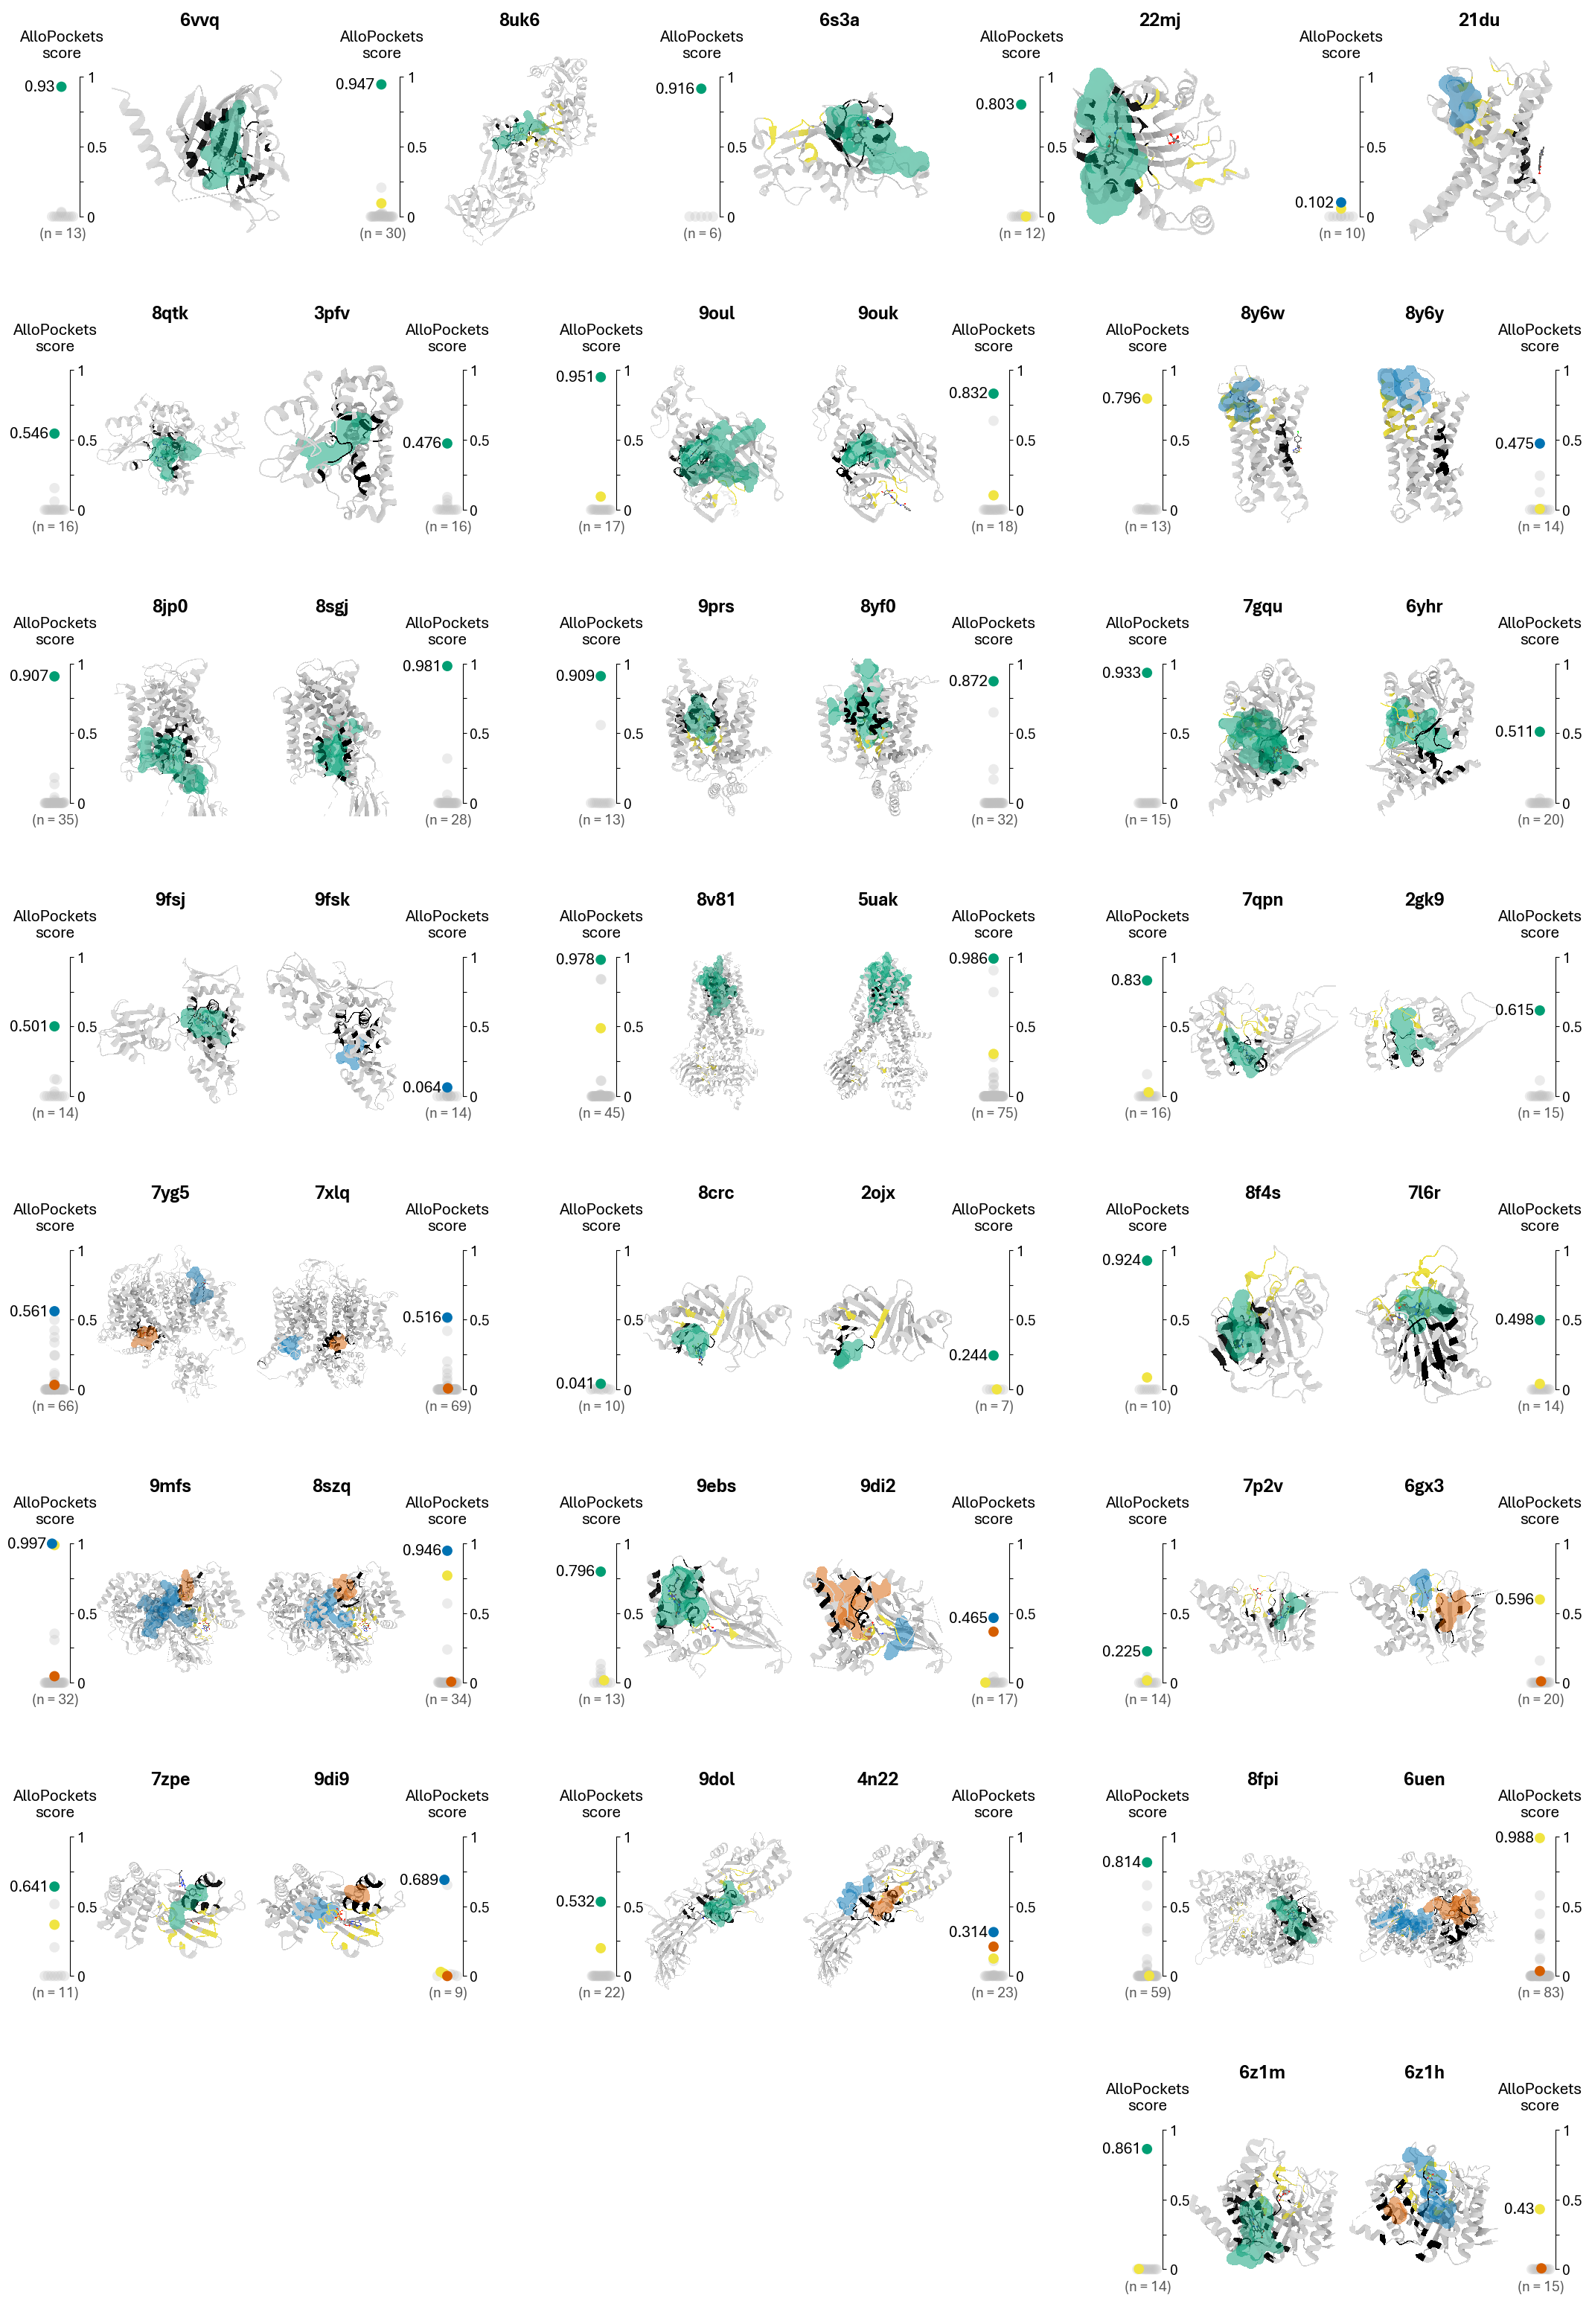

Saved combined figure to /home/fnerin/Desktop/AlloPockets/models/figure/holo_apo_multipanel.svg


In [14]:
combined_slots = []
combined_iter = iter(combined_entries)
for slot_id in range(1, ((FIGURE_CONFIG["rows"]-1) * FIGURE_CONFIG["columns"])+1):
    if slot_id in FIGURE_CONFIG["empty_panel_slots"]:
        combined_slots.append(None)
    else:
        combined_slots.append(next(combined_iter))

assert next(combined_iter, None) is None

fig = plt.figure(figsize=FIGURE_CONFIG["figsize"], facecolor=FIGURE_CONFIG["figure_facecolor"])
rows = fig.add_gridspec(
    FIGURE_CONFIG["rows"],
    1,
    left=FIGURE_CONFIG["left"],
    right=FIGURE_CONFIG["right"],
    top=FIGURE_CONFIG["top"],
    bottom=FIGURE_CONFIG["bottom"],
    hspace=FIGURE_CONFIG["outer_hspace"],
)

panel_counter = 0

top_row = rows[0].subgridspec(1, len(holo_only_entries), wspace=FIGURE_CONFIG["top_row_wspace"])
for col_idx, panel_data in enumerate(holo_only_entries):
    panel_label = f"{ascii_lowercase[panel_counter]})"
    draw_panel(fig, top_row[0, col_idx], panel_label, panel_data["panel_title"], panel_data["items"], FIGURE_CONFIG)
    panel_counter += 1

for row_idx in range((FIGURE_CONFIG["rows"]-1)):
    row_grid = rows[row_idx + 1].subgridspec(1, FIGURE_CONFIG["columns"], wspace=FIGURE_CONFIG["combined_row_wspace"])
    for col_idx in range(FIGURE_CONFIG["columns"]):
        slot_idx = row_idx * FIGURE_CONFIG["columns"] + col_idx # FIGURE_CONFIG["columns"] WAS ORIGINALLY A 3
        panel_data = combined_slots[slot_idx]
        if panel_data is None:
            empty_ax = fig.add_subplot(row_grid[0, col_idx])
            empty_ax.set_facecolor(FIGURE_CONFIG["panel_facecolor"])
            empty_ax.axis("off")
            continue

        panel_label = f"{ascii_lowercase[panel_counter]})"
        draw_panel(fig, row_grid[0, col_idx], panel_label, panel_data["panel_title"], panel_data["items"], FIGURE_CONFIG)
        panel_counter += 1

# assert panel_counter == 21

fig.savefig(FIGURE_CONFIG["output_path"], transparent=True)
plt.show()
print(f"Saved combined figure to {FIGURE_CONFIG['output_path']}")